# Day 1 — Sprint 1 Planning and Neural Network Architecture
## Project: Cardiac Patient Monitoring System
### Dataset
Heart Disease Health Indicators Dataset
### Main Objective
Objective of this notebook is to:
1. Confirm the final dataset for the project.
2. Perform basic inspection and EDA on data.
3. Determine class imbalance and perform analysis on it.
4. Separate the data into training and test datasets.
5. Apply SMOTE technique on the training data set alone.
6. Train a Logistic Regression Baseline model.
7. Evaluate the model using Accuracy, Precision, Recall, F1-score, and Confusion Matrix.
8. Get to know basics of Neural Networks.
9. Decide the Neural Network architecture that would be implemented in coming days.
10. Set the baseline for future improvements.

# 1. Sprint 1 Planning
## Sprint Goal
The aim of Sprint 1 is to have a solid baseline model of the Cardiac Patient Monitoring System and prepare the dataset for the development of Neural Networks.
## Sprint 1 Backlog
- Complete the Heart Disease dataset.
- Look into the structure of the dataset.
- Check for any missing values.
- Check for any duplicates.
- Target Variable Analysis.
- Investigate the issue of class imbalance.
- Separate the dataset into training and test datasets.
- Address the class imbalance with SMOTE on the training dataset.
- Scale the variables.
- Create a logistic regression baseline model.
- Test the baseline model.
- Track the baseline results.
- Get familiar with the Neural Network architecture.
- Create the Neural Network architecture.
## Sprint 1 Success Criteria
A Sprint 1 can be deemed successful if:
- The dataset is cleaned and analyzed.
- Target variable is identified.
- The problem of class imbalance is addressed.
- There is no data leakage between training and test data.
- A baseline classifier is created.
- Metrics for the baseline model are tracked.
- Neural Network architecture is established.

## Choice of Dataset
- Data source: Kaggle
https://www.kaggle.com/datasets/alexteboul/heart-disease-health-indicators-dataset
- Dataset name: Heart Disease Health Indicators Dataset
- Description: The dataset includes health, lifestyle, and demographic data about heart disease.
- Target Variable:
HeartDisease
- Target class values:
Yes – there is heart disease
No – there is no heart disease
Therefore, this is a **binary classification problem**.

## Import Libraries

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report)
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings("ignore")

## Load the Dataset

In [7]:
df = pd.read_csv("heart_disease_health_indicators_BRFSS2015.csv")

## Initial Dataset Inspection (First Ten Rows,Dataset Shape,Column Names,Data Types and Non-Null Values)

In [9]:
df.head(10)

,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
5,0.0,1.0,1.0,1.0,25.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,2.0,0.0,1.0,10.0,6.0,8.0
6,0.0,1.0,0.0,1.0,30.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,3.0,0.0,14.0,0.0,0.0,9.0,6.0,7.0
7,0.0,1.0,1.0,1.0,25.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,0.0,0.0,1.0,0.0,11.0,4.0,4.0
8,1.0,1.0,1.0,1.0,30.0,1.0,0.0,2.0,0.0,1.0,...,1.0,0.0,5.0,30.0,30.0,1.0,0.0,9.0,5.0,1.0
9,0.0,0.0,0.0,1.0,24.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,2.0,0.0,0.0,0.0,1.0,8.0,4.0,3.0


In [10]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 253680
Number of columns: 22


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   HeartDiseaseorAttack  253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   Diabetes              253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  MentHlth   

These checks provide basic insights into the structure of the dataset, number of observations, columns, and types of data.

## Check Missing Values

In [12]:
df.isnull().sum()

HeartDiseaseorAttack    0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
Diabetes                0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

Missing values can cause problems during preprocessing and model training.
If missing values exist, they should be handled before training.
In this dataset, the columns are expected to contain no missing values.

## Check Duplicates

In [14]:
df.duplicated().sum()

np.int64(23899)

In [15]:
df = df.drop_duplicates()

### Remove Duplicate Rows
The dataset contained **23,899 duplicate rows**. These duplicate records were removed to ensure that each observation is counted only once and to avoid biasing the statistical analysis and EDA.
After removing duplicates, the dataset contains 229,781 rows and 22 columns.

## Target Variable
The target variable is:
**HeartDiseaseorAttack**
It represents whether a patient having heart disease.

In [18]:
target = "HeartDiseaseorAttack"
print(df[target].value_counts())

HeartDiseaseorAttack
0.0    206064
1.0     23717
Name: count, dtype: int64


## Target Percentage

In [20]:
target_percentage = (df[target].value_counts(normalize=True).mul(100).round(2))
print(target_percentage)

HeartDiseaseorAttack
0.0    89.68
1.0    10.32
Name: proportion, dtype: float64


## Class Imbalance
The target variable is highly imbalanced.
The majority class represents respondents who did not report heart
disease or heart attack, while the minority class represents respondents
who did.
After removing duplicate rows, the target variable contains:
- **206,064 observations (89.68%)** in the majority class.
- **23,717 observations (10.32%)** in the minority class.
This confirms that the target variable is highly imbalanced, with the positive class representing approximately 10% of the observations.
### Why is this a problem?
If we train a model directly on this imbalanced data, the model may
become biased toward the majority class.
For example, a model could predict "No Heart Disease" for most patients
and still achieve a relatively high accuracy.
However, this would not mean that the model is good at detecting patients
with heart disease.
For a healthcare-related classification problem, correctly identifying
the positive class is important.
Therefore, we will handle the class imbalance before evaluating our
baseline model.

## Exploratory Data Analysis (EDA)
Before building the baseline model, we perform a brief Exploratory Data
Analysis to understand the structure and important patterns in the data.
The EDA focuses on:
- Target distribution
- Important health-related features
- Relationships between selected features and heart disease
- Correlations between variables
The purpose of this EDA is not to build the final model, but to understand
the dataset and identify useful patterns before modeling.

## Visualize Class Imbalance

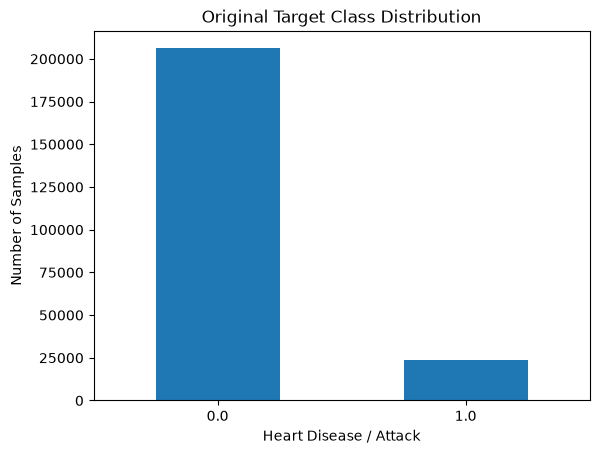

In [21]:
df[target].value_counts().plot(kind="bar")
plt.title("Original Target Class Distribution")
plt.xlabel("Heart Disease / Attack")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.show()

## Age Distribution

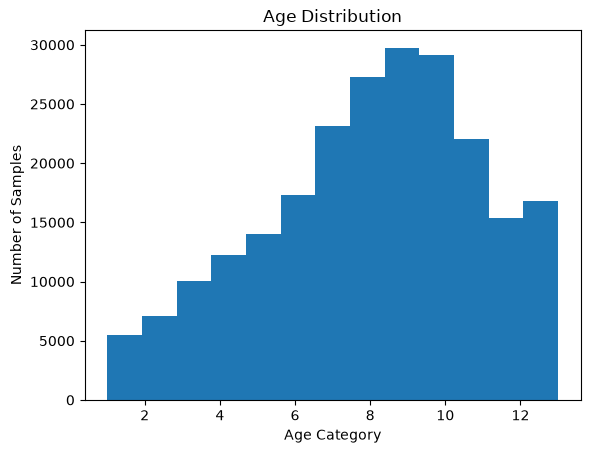

In [22]:
plt.hist(df["Age"], bins=13)
plt.title("Age Distribution")
plt.xlabel("Age Category")
plt.ylabel("Number of Samples")
plt.show()

### Plot Analysis
The dataset contains respondents from different age categories.
The distribution allows us to understand which age groups are more
represented in the dataset.
Age is expected to be an important health-related feature because the
risk of cardiovascular disease generally increases with age.

## BMI Distribution

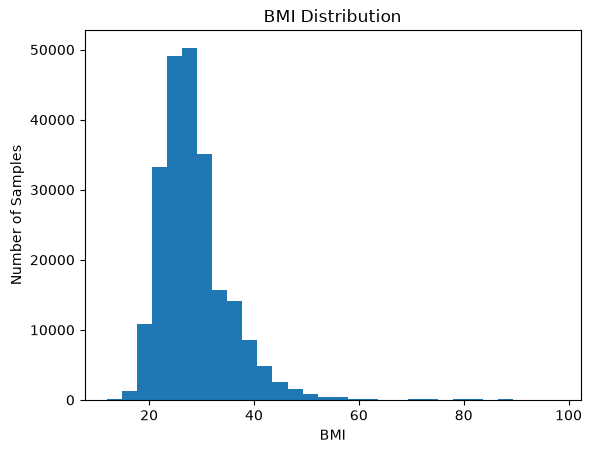

In [23]:
plt.hist(df["BMI"], bins=30)
plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Number of Samples")
plt.show()

### Plot Analysis
BMI shows the distribution of body mass index across the respondents.
The distribution helps us identify the typical BMI range and whether
there are extreme values that may require further investigation.

## High Blood Pressure vs Heart Disease

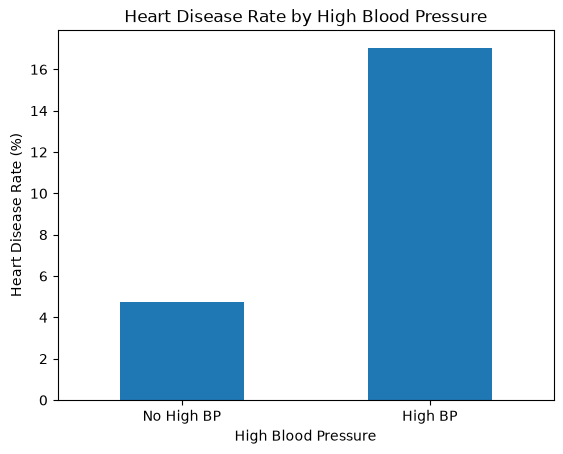

In [24]:
bp_rate = (df.groupby("HighBP")["HeartDiseaseorAttack"].mean().mul(100))
bp_rate.plot(kind="bar")
plt.title("Heart Disease Rate by High Blood Pressure")
plt.xlabel("High Blood Pressure")
plt.ylabel("Heart Disease Rate (%)")
plt.xticks([0, 1],["No High BP", "High BP"],rotation=0)
plt.show()

###  Plot Analysis
The plot compares the percentage of respondents with reported heart
disease or heart attack between people with and without high blood
pressure.
The heart disease rate is higher among respondents with high blood
pressure.
This suggests that HighBP may be an informative feature for predicting
the target.

## General Health vs Heart Disease

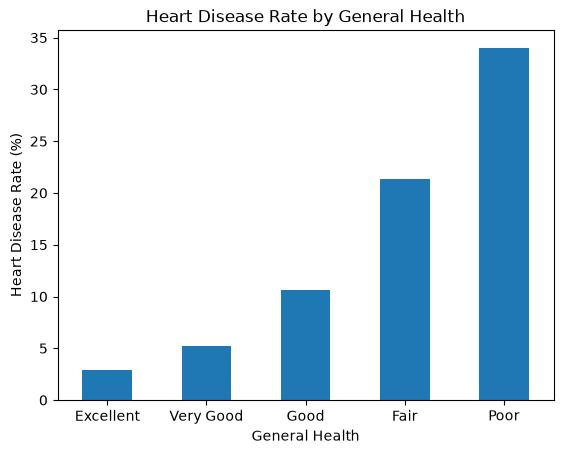

In [25]:
health_rate = (df.groupby("GenHlth")["HeartDiseaseorAttack"].mean().mul(100))
health_rate.plot(kind="bar")
plt.title("Heart Disease Rate by General Health")
plt.xlabel("General Health")
plt.ylabel("Heart Disease Rate (%)")
plt.xticks([0, 1, 2, 3, 4],["Excellent", "Very Good", "Good", "Fair", "Poor"],rotation=0)
plt.show()

###  Plot Analysis
The plot shows the relationship between self-reported general health
and heart disease.
Respondents with poorer general health tend to have a higher rate of
reported heart disease or heart attack.
This suggests that GenHlth may be an informative feature for the model.

## Correlation Heatmap

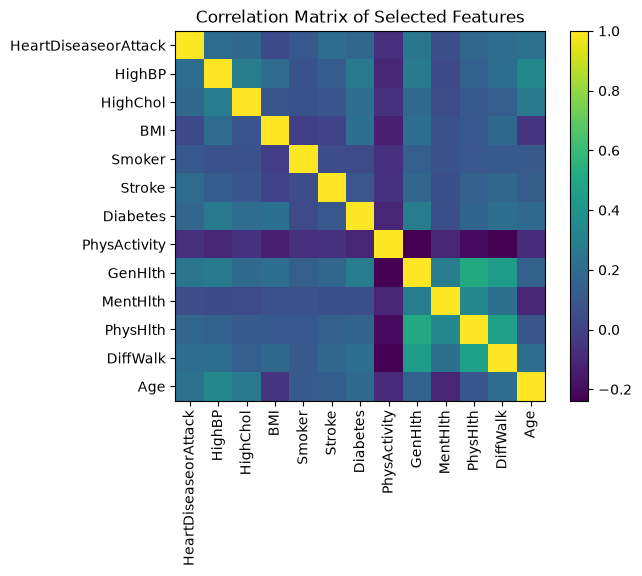

In [27]:
correlation_features = ["HeartDiseaseorAttack","HighBP","HighChol","BMI","Smoker","Stroke","Diabetes","PhysActivity","GenHlth","MentHlth","PhysHlth","DiffWalk","Age"]
corr_matrix = df[correlation_features].corr()
plt.imshow(corr_matrix)
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)),corr_matrix.columns,rotation=90)
plt.yticks(range(len(corr_matrix.columns)),corr_matrix.columns)
plt.title("Correlation Matrix of Selected Features")
plt.show()

### Plot Analysis
The correlation matrix provides an overview of the relationships between
the selected variables.
Some health-related variables show stronger relationships with the
target than others.
However, correlation alone does not determine whether a feature is
important for the final model.
The Neural Network and other machine learning models will learn the
relationships between the features during training.

## EDA Summary
These observations help us understand the dataset before building the
baseline model.
The most important preprocessing issue identified during EDA is the
strong class imbalance.
Therefore, SMOTE will be applied only to the training data before
training the baseline model.

## Separate Features and Target

In [34]:
x = df.drop(target, axis=1)
y = df[target]
print("x shape:", x.shape)
print("y shape:", y.shape)

x shape: (229781, 21)
y shape: (229781,)


## Train/Test Split — before SMOTE

In [35]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.20,random_state=42,stratify=y)
print("Training samples:", x_train.shape[0])
print("Testing samples:", x_test.shape[0])

Training samples: 183824
Testing samples: 45957


## Why Train/Test Split Before SMOTE
This is very important because the test set must represent unseen,
real-world data.
### Correct order:
Original Dataset-->Train / Test Split-->Apply SMOTE only to Training Data-->Train Model-->Evaluate on Original Test Data
We must NOT apply SMOTE to the complete dataset before splitting.
Otherwise, synthetic information generated from the minority class
could indirectly reach the test set, causing data leakage and producing
overly optimistic evaluation results.
The test set will therefore remain untouched and imbalanced.
Only the training data will be balanced.

### Check Training Distribution Before SMOTE

In [36]:
print("Training class distribution before SMOTE:")
print(y_train.value_counts())

Training class distribution before SMOTE:
HeartDiseaseorAttack
0.0    164850
1.0     18974
Name: count, dtype: int64


## Apply SMOTE

In [38]:
smote = SMOTE(random_state=42)
x_train_resampled, y_train_resampled = smote.fit_resample(x_train,y_train)

## Check Distribution After SMOTE

In [39]:
print("Training class distribution after SMOTE:")
print(y_train_resampled.value_counts())

Training class distribution after SMOTE:
HeartDiseaseorAttack
0.0    164850
1.0    164850
Name: count, dtype: int64


In [41]:
print(y_train_resampled.value_counts(normalize=True).mul(100).round(2))

HeartDiseaseorAttack
0.0    50.0
1.0    50.0
Name: proportion, dtype: float64


### Visualize Before vs After

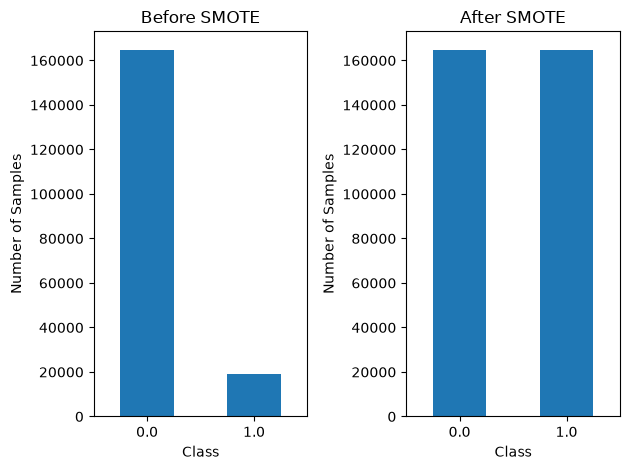

In [42]:
fig, axes = plt.subplots(1, 2)
y_train.value_counts().plot(kind="bar",ax=axes[0])
axes[0].set_title("Before SMOTE")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Number of Samples")
axes[0].tick_params(axis="x", rotation=0)
y_train_resampled.value_counts().plot(kind="bar",ax=axes[1])
axes[1].set_title("After SMOTE")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Number of Samples")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## 5. Handling Class Imbalance with SMOTE
We use **SMOTE (Synthetic Minority Over-sampling Technique)** to handle
the class imbalance.
SMOTE creates new synthetic samples for the minority class based on
existing minority-class observations.
The goal is to provide the model with a more balanced training dataset.
### Important:
SMOTE is applied ONLY to the training data,the test data is not modified.
This allows us to evaluate the model on data that still represents the
original real-world class distribution.
### Before SMOTE
The minority class was significantly smaller than the majority class.
### After SMOTE
The two training classes have approximately equal numbers of samples.
This gives the model a better opportunity to learn patterns associated with the minority class.

## Feature Scaling

In [43]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_resampled)
x_test_scaled = scaler.transform(x_test)

### Feature Scaling
Once class imbalance is addressed, we proceed with feature scaling.
Feature scaling scales the features to make them:
- Mean = 0
- Standard deviation = 1
This is important for algorithms like logistic regression and neural
networks, where features can be of different magnitudes.
### Important
The scaler is trained using the training data only,the same transformation is applied to the testing data.
This ensures that no data from the testing set influences the training process.

## Baseline Model
Before building a Neural Network, we need a simple baseline model.
We use **Logistic Regression** as our baseline because:
- The problem is binary classification.
- Logistic Regression is simple and interpretable.
- It provides a strong reference point.
- Future Neural Network models can be compared against it.
The baseline is important because a more complex model is not
automatically a better model.
The Neural Network should demonstrate an improvement over this baseline.

In [45]:
baseline_model = LogisticRegression(max_iter=1000,random_state=42)
baseline_model.fit(x_train_scaled, y_train_resampled)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [46]:
y_pred = baseline_model.predict(x_test_scaled)

### Evaluation Metrics

In [48]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"Accuracy : {accuracy}")
print(f"Precision: {precision}")
print(f"Recall   : {recall}")
print(f"F1-score : {f1}")

Accuracy : 0.7450225210522881
Precision: 0.25572599285564196
Recall   : 0.7697659709044908
F1-score : 0.3839116719242902


## Evaluation Metrics Results Analysis
The following metrics are used to evaluate the baseline model.
### Accuracy
Accuracy evaluates the percentage of correct predictions among all predictions.
But if there are cases of imbalance in the data set, then accuracy
alone can be deceptive.
### Precision
Precision evaluates:
"Out of all the patients predicted to be suffering from heart
disease, how many actually fall under the positive class?"
### Recall
Recall evaluates:
"Out of all the patients who are actually suffering from heart
disease, how many did our model identify as such?"
Recall is particularly significant for this project since a missed
prediction of a patient suffering from heart disease is a more severe
error than a false positive prediction.
### F1-score
F1-score evaluates the combination of Precision and Recall.
It is helpful when there is an imbalance between the classes.

### Classification Report

In [49]:
print(classification_report(y_test,y_pred,target_names=["No Heart Disease", "Heart Disease"]))

                  precision    recall  f1-score   support

No Heart Disease       0.97      0.74      0.84     41214
   Heart Disease       0.26      0.77      0.38      4743

        accuracy                           0.75     45957
       macro avg       0.61      0.76      0.61     45957
    weighted avg       0.89      0.75      0.79     45957



### Confusion Matrix

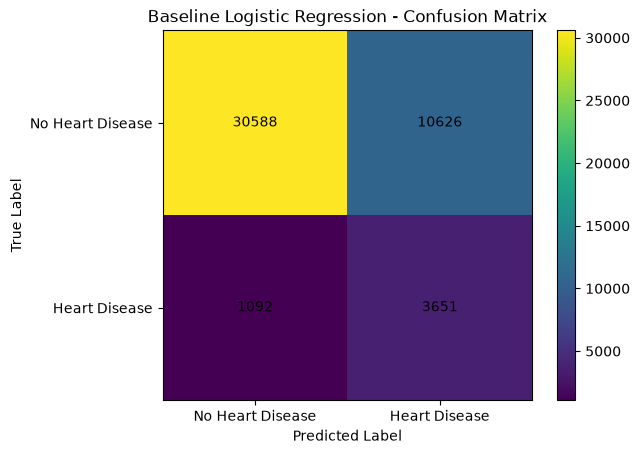

In [51]:
cm = confusion_matrix(y_test, y_pred)
plt.imshow(cm)
plt.title("Baseline Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([0, 1],["No Heart Disease", "Heart Disease"])
plt.yticks([0, 1],["No Heart Disease", "Heart Disease"])
for i in range(2):
    for j in range(2):plt.text(j,i,cm[i, j],ha="center",va="center")
plt.colorbar()
plt.show()

### Baseline Logistic Regression - Confusion Matrix Analysis
The confusion matrix above evaluates the performance of the baseline Logistic Regression model on the heart disease dataset:
* **True Negatives (No Heart Disease correctly predicted):** `30,588`
* **False Positives (No Heart Disease incorrectly predicted as Heart Disease):** `10,626`
* **False Negatives (Heart Disease incorrectly predicted as No Heart Disease):** `1,092`
* **True Positives (Heart Disease correctly predicted):** `3,651`
#### Performance Observations:
* **High Sensitivity / Low False Negatives:** The model successfully catches most actual positive cases (`1,092` false negatives), which is crucial in a medical context to ensure patients with heart disease are rarely missed.
* **Low Specificity / High False Positives:** A large volume of healthy instances are misclassified as having heart disease (`10,626` false positives), leading to a high false alarm rate.
* **Accuracy Paradox:** While the overall raw accuracy might look deceptively high due to the massive number of True Negatives, the model struggles significantly with precision for the minority class.

### Save Results in DataFrame

In [ ]:
baseline_results = pd.DataFrame({"Model": ["Logistic Regression + SMOTE"],"Accuracy": [accuracy],"Precision": [precision],"Recall": [recall],"F1 Score": [f1]})
baseline_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression + SMOTE,0.745023,0.255726,0.769766,0.383912


#### Baseline Result
After handling class imbalance using SMOTE on the training data,
the Logistic Regression model achieved the following results:
- Accuracy: 0.745023
- Precision: 0.255726
- Recall: 0.769766
- F1-score: 0.383912
This model is our baseline.
Any Neural Network developed in the next stages will be compared
against this baseline.
The goal is not simply to obtain a higher accuracy, but to achieve
good overall performance while maintaining strong Recall and F1-score.

## Neural Network Architecture
### Why Deep Learning?
Classical Machine Learning models such as Logistic Regression,
Decision Trees, and Random Forests work well with structured tabular
data.
Neural Networks can learn complex non-linear relationships between
features.
A Neural Network is composed of interconnected neurons organized
into layers.
The basic operation of a neuron is:
z = dot(inputs, weights) + bias
Then an activation function is applied:
output = activation(z)
Therefore, a Neural Network is essentially many of these operations
connected together.

#### The Neuron
A neuron receives input values.
Each input is multiplied by a learned weight.
The weighted values are summed together and a bias is added.
The result is passed through an activation function.
### Formula
z = x1*w1 + x2*w2 + ... + xn*wn + b
output = activation(z)
The weights and bias are learned during training.

### Neuron Example

In [53]:
inputs = np.array([0.5, 0.8, 0.2])
weights = np.array([0.4, -0.2, 0.7])
bias = 0.1
z = np.dot(inputs, weights) + bias
print("Neuron weighted sum + bias:", z)

Neuron weighted sum + bias: 0.2799999999999999


## Activation Functions
Activation functions allow Neural Networks to learn non-linear
relationships.
Common activation functions include:
- ReLU
- Sigmoid
- Tanh
### ReLU
ReLU is commonly used in hidden layers.
ReLU(x) = max(0, x)
### Sigmoid
Sigmoid produces values between 0 and 1.
It is commonly used in the output layer for binary classification.
sigmoid(x) = 1 / (1 + e^-x)

## Neural Network Layers
### Input Layer
The input layer receives the features.
Our dataset contains multiple health and demographic features,
so the input layer will contain one input for each feature.
### Hidden Layers
Hidden layers learn intermediate patterns and representations.
Adding more hidden layers allows the network to learn increasingly
complex relationships.
### Output Layer
The output layer produces the final prediction.
Because this project is binary classification, we will use:
- 1 output neuron
- Sigmoid activation
The output represents the probability of the positive class.

## What Does "Deep" Mean?
A Neural Network is considered deep when it contains multiple hidden
layers.
For example:
Input --> Hidden --> Output
is a shallow network.
While:
Input → Hidden → Hidden → Output
contains multiple hidden layers and is considered deeper.
Each layer transforms the representation received from the previous layer.
This allows the network to learn increasingly complex patterns.

## Weights and Biases
Weights and biases are the learnable parameters of a Neural Network.
### Weights
Weights determine how strongly each input contributes to a neuron's
output.
### Bias
The bias allows the neuron to shift its activation.
During training, the model updates these parameters to reduce the
difference between predictions and actual labels.
The training process can be summarized as:
Random weights and biases-->Prediction-->Calculate error-->Update parameters-->Better prediction

## Proposed Neural Network Architecture
Based on the project requirements and the binary classification problem, the initial Neural Network architecture will be:
**Input Layer --> Dense(64, ReLU) --> Dense(32, ReLU) --> Output Layer(1, Sigmoid)**
### Architecture Details
- **Input Layer:** 21 input features.
- **Hidden Layer 1:** 64 neurons with ReLU activation.
- **Hidden Layer 2:** 32 neurons with ReLU activation.
- **Output Layer:** 1 neuron with Sigmoid activation for binary classification.
This architecture provides multiple hidden layers, so it is considered a deep neural network.
The architecture is intentionally kept simple as an initial design. It can be adjusted in later days based on training performance and comparison with the Logistic Regression baseline.

# 12. Why the Baseline Matters
A Neural Network is more complex than Logistic Regression, but
complexity does not automatically mean better performance.
The baseline gives us a reference point.
For example:
Logistic Regression F1 = 0.383912
Then the Neural Network should aim for:
Neural Network F1 >0.383912
The comparison should consider multiple metrics, especially:
- Recall
- Precision
- F1-score
rather than relying only on Accuracy.

# Day 1 — Tasks Completion Summary
All Day 1 hands-on tasks were completed successfully.
### Step 1: Complete Sprint 1 planning: confirm the goal and select the first backlog tasks.
The Sprint 1 goal and backlog were defined, focusing on dataset finalization, EDA, baseline modeling, and preparation for the Neural Network.
### Step 2: Finalize the project dataset and complete a brief EDA in the project notebook.
The Heart Disease Health Indicators dataset was finalized, inspected, cleaned, and analyzed through descriptive checks and visual EDA.
### Step 3: Train a simple baseline model (e.g. logistic/linear regression from Week 3) and record its metric.
A Logistic Regression baseline was trained after applying SMOTE only to the training data and scaling the features.
### Step 4: Commit the baseline notebook to a feature branch and open a draft pull request.
The Day 1 baseline notebook was version-controlled using Git and GitHub.
- Created a dedicated feature branch: `feature/day1-baseline`
- Committed the baseline notebook changes to the feature branch.
- Pushed the feature branch to GitHub.
- Prepared the branch for review through a Draft Pull Request targeting `main`.
This workflow keeps the `main` branch stable while allowing new work to be reviewed before merging.
### Step 5: In Markdown, state the baseline score every later model must beat.
The Logistic Regression baseline was established with an F1-score of **0.383912**. This score will be used as the reference point for evaluating future Neural Network models.
### Neural Network Architecture
The basic Neural Network concepts were studied, including neurons, weights, biases, activation functions, input/hidden/output layers, and the meaning of deep learning. An initial architecture was also proposed for implementation in the following days.